# Data Overview

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load Dataset

In [2]:
hurricanes = pd.read_csv("data/cleaned_data.csv") # renamed kaggle csv from storms to hurricane_data

### Inspect Dataset

In [3]:
print(hurricanes.head())
print(hurricanes.info())
print(hurricanes.columns)

                  name  year  month  day  hour   lat  long     status  \
0              Blanche  1975      7   27    60  35.9 -70.0  hurricane   
1              Blanche  1975      7   27    12  36.9 -69.0  hurricane   
2              Blanche  1975      7   27    18  37.9 -68.0  hurricane   
3              Blanche  1975      7   28     0  39.3 -67.2  hurricane   
4              Blanche  1975      7   28    60  41.2 -66.4  hurricane   

   category  wind  pressure  tropicalstorm_force_diameter  \
0       1.0    65       987                           212   
1       1.0    70       984                           220   
2       1.0    75       981                           230   
3       1.0    75       980                           730   
4       1.0    70       980                           492   

   hurricane_force_diameter  hurricane_class  
0                        59                0  
1                        63                0  
2                        64                0  
3     

NOTES: The dataset contains 5,100 hurricane observations and 14 variables. Variables include temporal information (year, month, day, hour), geographic location (latitude and longitude), storm intensity measures (wind, pressure), storm size measures, and hurricane category.

# EDA: Hurricane observations

### Summary Statistics

In [40]:
print("=== Hurricane Category Counts ===")
category_counts = hurricanes['category'].value_counts().sort_index()
print(category_counts)
print("\n=== Hurricane Category Percentages ===")
category_percentages = (
    hurricanes['category'].value_counts(normalize=True)
    .sort_index() * 100
)

print(category_percentages.round(2))
print("=== Numerical Variable Summary ===")
display(hurricanes.describe())

=== Hurricane Category Counts ===
category
1.0    2707
2.0    1046
3.0     632
4.0     586
5.0     129
Name: count, dtype: int64

=== Hurricane Category Percentages ===
category
1.0    53.08
2.0    20.51
3.0    12.39
4.0    11.49
5.0     2.53
Name: proportion, dtype: float64
=== Numerical Variable Summary ===


,year,month,day,hour,lat,long,category,wind,pressure,tropicalstorm_force_diameter,hurricane_force_diameter,hurricane_class
count,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5099.000000,5100.000000,5100.00000,5100.000000,5100.000000,5100.000000,5100.000000
mean,2002.482353,8.955490,15.805098,22.860784,26.428667,-63.897235,1.898824,86.67549,968.609020,256.289608,65.301176,0.264118
std,13.633805,0.963839,8.987628,22.696014,8.101691,16.713813,1.154117,20.71107,18.711738,105.954981,33.402075,0.440905
min,1975.000000,1.000000,1.000000,0.000000,9.500000,-119.300000,1.000000,65.00000,882.000000,50.000000,10.000000,0.000000
25%,1993.000000,8.000000,8.000000,12.000000,19.800000,-76.200000,1.000000,70.00000,957.000000,200.000000,45.000000,0.000000
50%,2003.000000,9.000000,16.000000,18.000000,26.300000,-63.200000,1.000000,80.00000,973.000000,230.000000,60.000000,0.000000
75%,2015.000000,9.000000,24.000000,30.000000,32.400000,-51.650000,3.000000,100.00000,983.000000,295.000000,75.000000,1.000000
max,2024.000000,12.000000,31.000000,94.000000,50.800000,-14.100000,5.000000,165.00000,1005.000000,870.000000,300.000000,1.000000


NOTES:
Hurricane Categories
Category 1 hurricanes represent over half of all observations (53.08%), while Category 5 hurricanes account for only 2.53%. This indicates an imbalance toward weaker hurricanes.

Numerical Variables
The maximum value of 94 for hour appears unusual since valid observation hours are typically 0, 6, 12, or 18 UTC. This may represent a data quality issue or special coding convention and should be investigated before modeling.

### Distribution Analysis

#### Wind Speed and Pressure Histogram

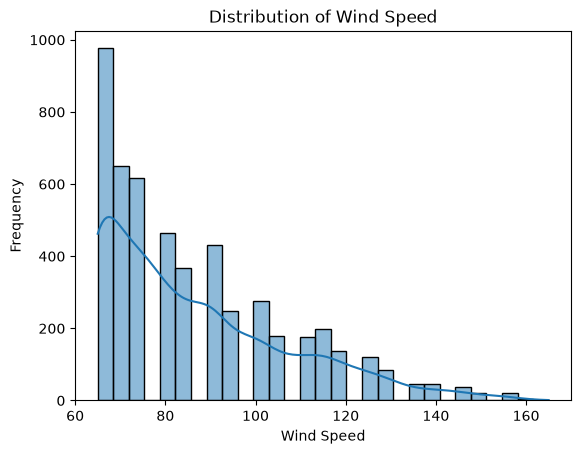

In [10]:
sns.histplot(hurricanes['wind'], kde=True)

plt.title("Distribution of Wind Speed")
plt.xlabel("Wind Speed")
plt.ylabel("Frequency")

plt.show()

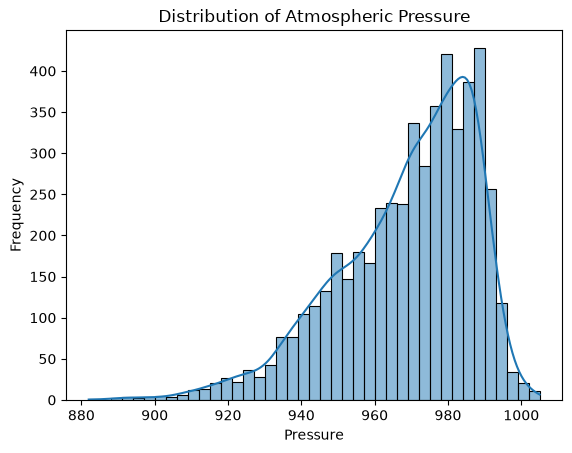

In [11]:
sns.histplot(hurricanes['pressure'], kde=True)

plt.title("Distribution of Atmospheric Pressure")
plt.xlabel("Pressure")
plt.ylabel("Frequency")

plt.show()

NOTES:
Wind Histogram
Wind speed is right-skewed, with most observations concentrated between 65 and 100 mph. Higher wind speeds occur less frequently and represent stronger hurricanes.

Pressure Histogram
Atmospheric pressure is left-skewed. Most observations occur between 950 and 995 mb, while very low pressures are relatively rare and correspond to stronger hurricanes.

#### Category Distribution


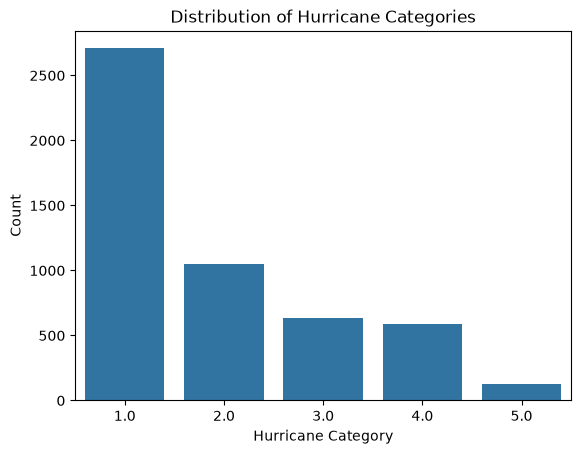

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='category', data=hurricanes)

plt.title("Distribution of Hurricane Categories")
plt.xlabel("Hurricane Category")
plt.ylabel("Count")

plt.show()

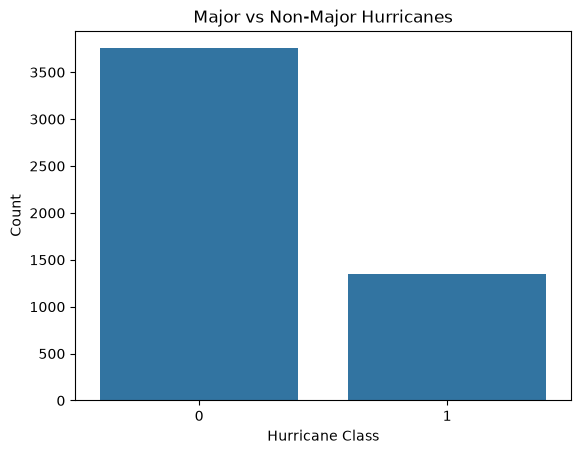

In [77]:
sns.countplot(
    x='hurricane_class',
    data=hurricanes
)

plt.title("Major vs Non-Major Hurricanes")
plt.xlabel("Hurricane Class")
plt.ylabel("Count")
plt.show()

NOTES: The distribution is imbalanced, with Category 1 storms dominating the dataset. Category 5 storms are relatively rare, which may affect predictive model performance.

### Correlation Analysis

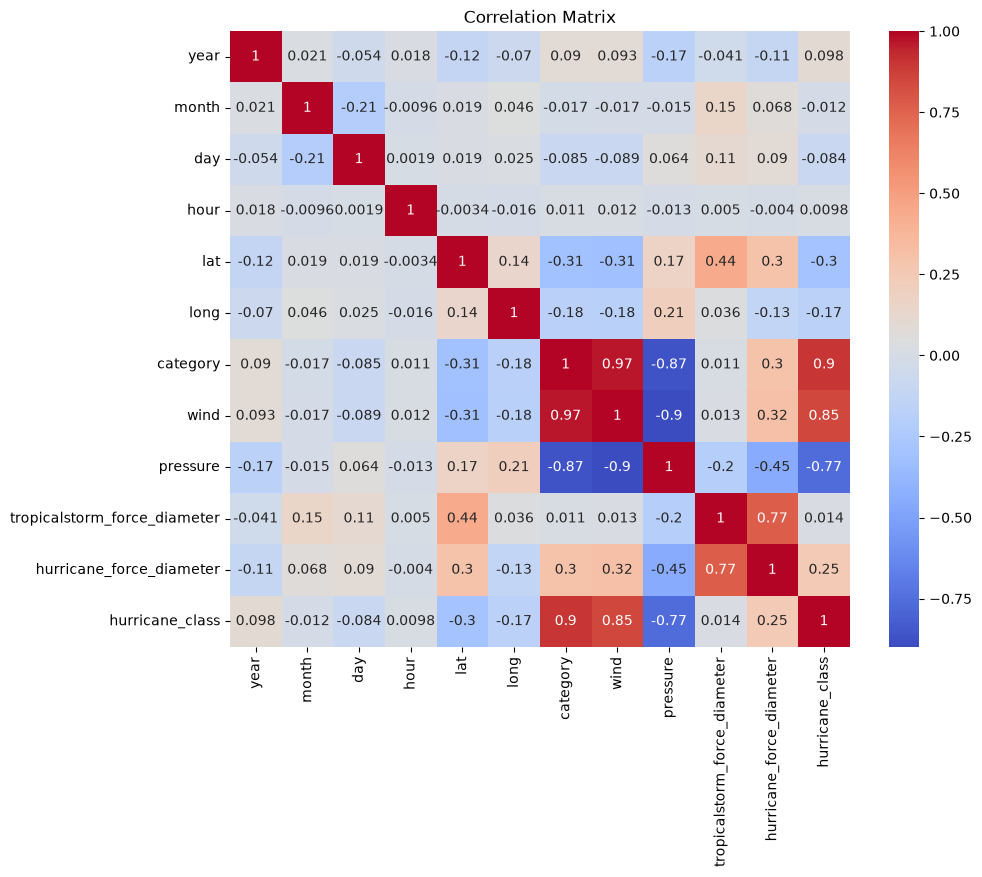

In [49]:
numeric_cols = hurricanes.select_dtypes(include='number')
correlation_matrix = numeric_cols.corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [57]:
corr_summary = (
    correlation_matrix['hurricane_class']
    .drop(['hurricane_class', 'category'])
    .sort_values(
        key=lambda x: abs(x),
        ascending=False
    )
)

corr_table = pd.DataFrame({
    'Variable': corr_summary.index,
    'Correlation with Hurricane Class': corr_summary.values
})

display(corr_table)

,Variable,Correlation with Hurricane Class
0,wind,0.846677
1,pressure,-0.766090
2,lat,-0.296294
3,hurricane_force_diameter,0.246509
4,long,-0.166157
5,year,0.098243
6,day,-0.084009
7,tropicalstorm_force_diameter,0.013946
8,month,-0.011558
9,hour,0.009790


NOTES: Wind speed (r = 0.85) and pressure (r = -0.77) are the strongest predictors of major hurricane classification. Latitude shows a moderate negative relationship (r = -0.30), while temporal variables contribute little predictive information.

#### Wind Analysis

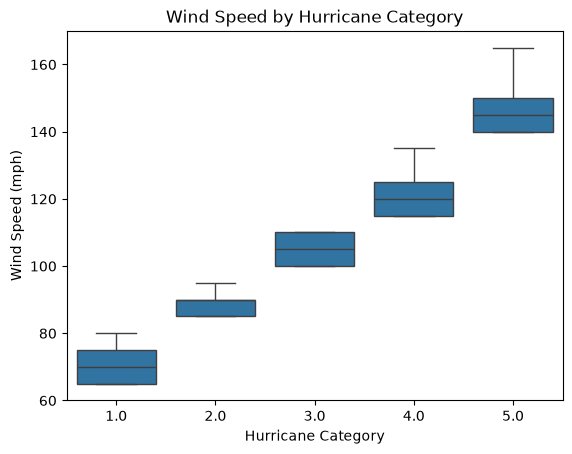

In [70]:
sns.boxplot(
    x='category',
    y='wind',
    data=hurricanes
)

plt.title("Wind Speed by Hurricane Category")
plt.xlabel("Hurricane Category")
plt.ylabel("Wind Speed (mph)")
plt.show()

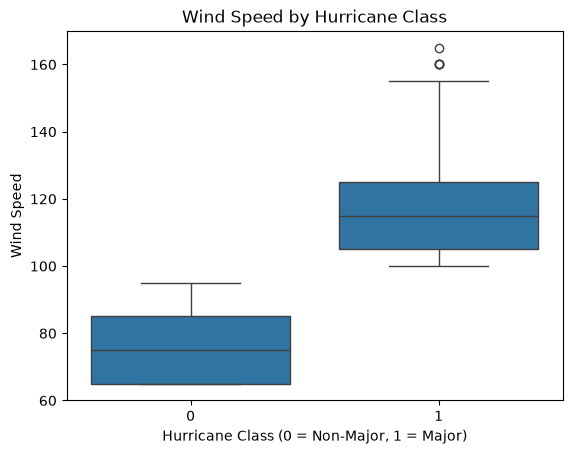

In [71]:
sns.boxplot(
    x='hurricane_class',
    y='wind',
    data=hurricanes
)

plt.title("Wind Speed by Hurricane Class")
plt.xlabel("Hurricane Class (0 = Non-Major, 1 = Major)")
plt.ylabel("Wind Speed")
plt.show()

NOTES:
Wind by Category
Median wind speed increases consistently across hurricane categories, confirming that wind speed is a defining characteristic of hurricane intensity.

Wind by Major Hurricane Class
Major hurricanes exhibit substantially higher wind speeds than non-major hurricanes, with minimal overlap between groups.

#### Wind Atmospheric Pressure

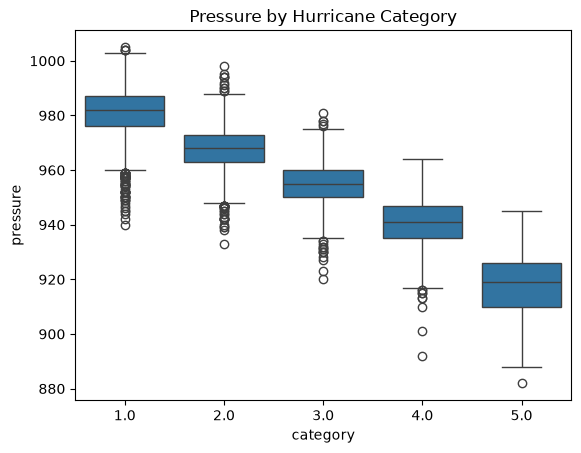

In [ ]:
sns.boxplot(x='category', y='pressure', data=hurricanes)
plt.title("Pressure by Hurricane Category")
plt.show()

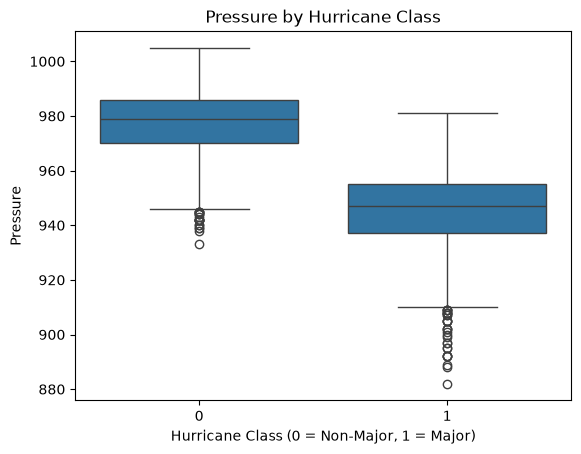

In [22]:
sns.boxplot(
    x='hurricane_class',
    y='pressure',
    data=hurricanes
)

plt.title("Pressure by Hurricane Class")
plt.xlabel("Hurricane Class (0 = Non-Major, 1 = Major)")
plt.ylabel("Pressure")
plt.show()

NOTES: 
Pressure by Category
Median atmospheric pressure decreases steadily as hurricane category increases.

Pressure by Hurricane Class
Major hurricanes exhibit significantly lower pressure values than non-major hurricanes, supporting pressure as an important predictor.

#### Wind vs Pressure Relationship

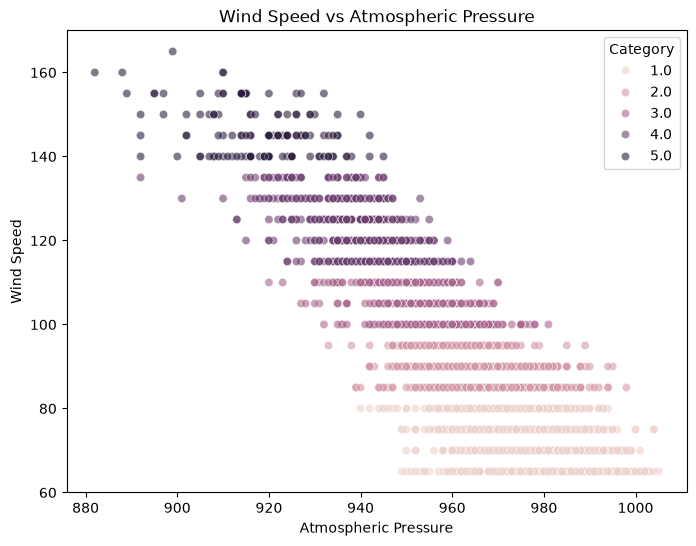

In [72]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='pressure',
    y='wind',
    hue='category',
    data=hurricanes,
    alpha=0.6
)

plt.title("Wind Speed vs Atmospheric Pressure")
plt.xlabel("Atmospheric Pressure")
plt.ylabel("Wind Speed")
plt.legend(title="Category")
plt.show()

Text(0.5, 1.0, 'Pressure vs Wind Speed by Hurricane Class')

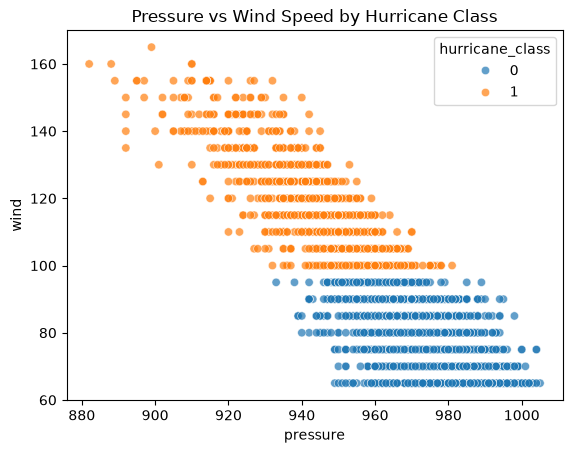

In [73]:
sns.scatterplot(
    x='pressure',
    y='wind',
    hue='hurricane_class',
    data=hurricanes,
    alpha=0.7
)

plt.title("Pressure vs Wind Speed by Hurricane Class")

<Axes: xlabel='pressure', ylabel='hurricane_force_diameter'>

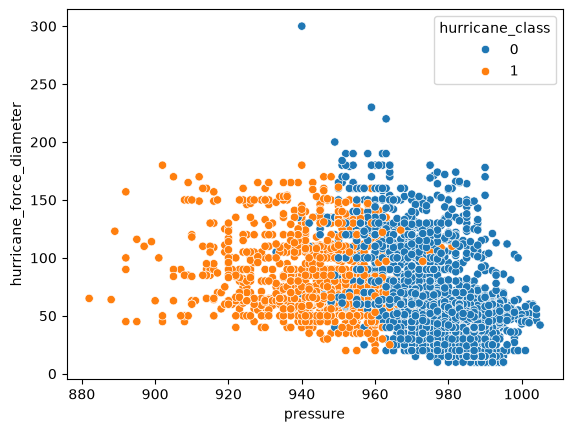

In [74]:
sns.scatterplot(
    x='pressure',
    y='hurricane_force_diameter',
    hue='hurricane_class',
    data=hurricanes
)

NOTES: A strong inverse relationship exists between wind speed and atmospheric pressure. As pressure decreases, wind speed increases. The separation between major and non-major hurricanes is visually apparent.

#### Geographic Analysis

In [21]:
import plotly.express as px

fig = px.scatter_geo(
    hurricanes,
    lat='lat',
    lon='long',
    color='category',
    hover_name='name',
    projection='natural earth',
    title='Atlantic Hurricane Locations'
)

fig.show()

<Axes: xlabel='lat', ylabel='wind'>

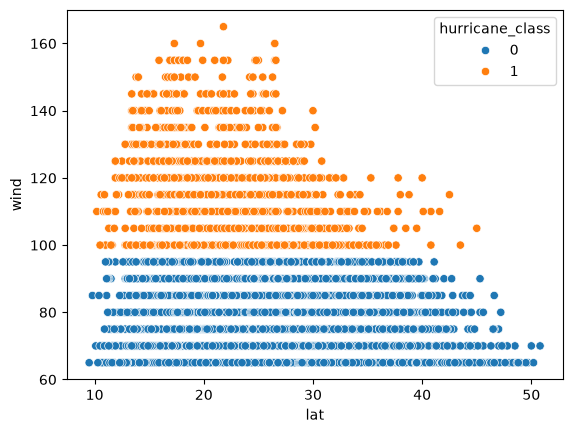

In [32]:
sns.scatterplot(
    x='lat',
    y='wind',
    hue='hurricane_class',
    data=hurricanes
)

<Axes: xlabel='lat', ylabel='pressure'>

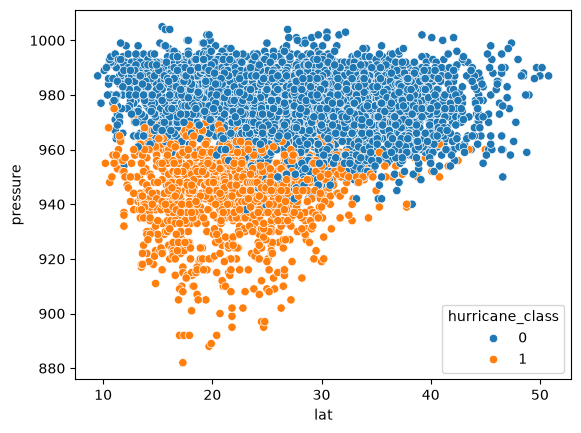

In [36]:
sns.scatterplot(
    x='lat',
    y='pressure',
    hue='hurricane_class',
    data=hurricanes
)

NOTES: Stronger hurricanes tend to occur more frequently at lower latitudes, although considerable overlap exists. Latitude demonstrates only moderate predictive power compared to wind speed and pressure.

#### Seasonal Analysis

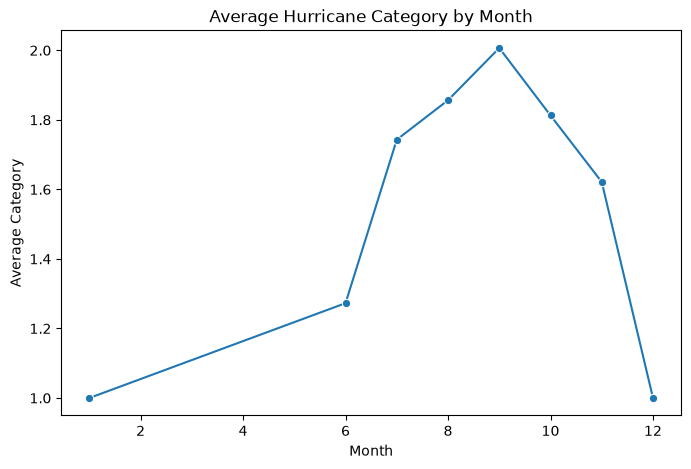

In [42]:
monthly_category = hurricanes.groupby('month')['category'].mean()

plt.figure(figsize=(8,5))

sns.lineplot(
    x=monthly_category.index,
    y=monthly_category.values,
    marker='o'
)

plt.title("Average Hurricane Category by Month")
plt.xlabel("Month")
plt.ylabel("Average Category")

plt.show()

In [44]:
monthly_major = hurricanes.groupby('month')['hurricane_class'].mean() * 100

print(monthly_major)

month
1      0.000000
6      9.090909
7     22.088353
8     24.771481
9     29.687500
10    23.946785
11    18.297872
12     0.000000
Name: hurricane_class, dtype: float64


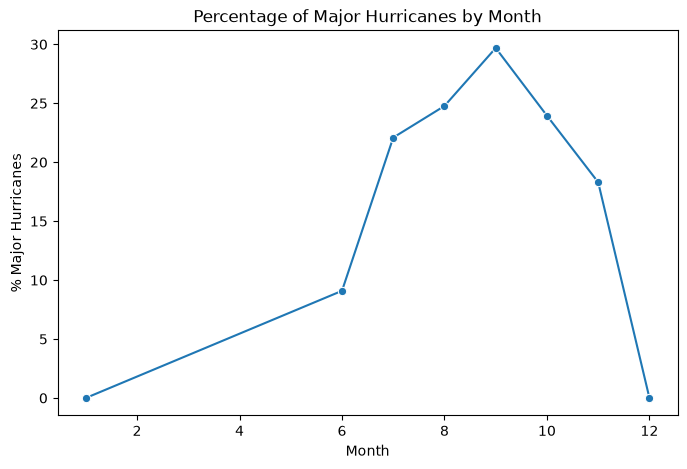

In [45]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x=monthly_major.index,
    y=monthly_major.values,
    marker='o'
)

plt.title("Percentage of Major Hurricanes by Month")
plt.xlabel("Month")
plt.ylabel("% Major Hurricanes")

plt.show()

NOTES:
Average Category
Hurricane intensity peaks during September, consistent with the Atlantic hurricane season.

Major Hurricane Percentage
The percentage of major hurricanes reaches its highest level during September and declines afterward.